# Car Price Prediction — AT82.03 Machine Learning, Assignment 2


**GitHub repository**: https://github.com/WinNawee/A2-Predicting_Car_Price

**Live site**: https://web-st127031.ml.brain.cs.ait.ac.th

**Task 1: building the tool.** A plain linear regression predicts price by learning a weight for each feature (year, mileage, power, etc.), one small step at a time (gradient descent). We added four things to that base class:
- `r2()`: how good the predictions are (0 = bad, 1 = perfect)
- Xavier initialization: a smarter way to pick the starting weights than all zeros
- momentum: carries some of the previous step forward, like a ball rolling downhill, so it doesn't get stuck in small bumps
- a feature importance plot, which inputs move the price the most

**Task 2: finding the best settings.** There's no way to know in advance which combination of settings works best, so we tried 180 of them (model type, momentum, batch method, weight init, learning rate) and scored each one with 3-fold cross validation (split the training data into 3 parts, train/check 3 times, average the result, so one lucky split doesn't fool us). The best one turned out to be plain linear regression, updating one row at a time (`sto`), no momentum (R² = 0.875) on the test set. Importantly, we picked the winner using only the validation scores, never the test set, then checked the test set exactly once at the very end, otherwise the reported score would look better than it really is.

**Task 3: turning it into a website.** The model above is wired into a 3-page web app: a home page that compares the old and new model honestly (the old one is more accurate, the new one is more transparent since every coefficient is visible), the old model page from Assignment 1, and the new model page which also shows a typical price range instead of a single exact number. The whole app is packaged with Docker so it runs the same way on any machine, including the course server.

## Setup

In [1]:
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
SEED = 7  # fixed once

sns.set_theme(style="ticks")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)


## 1. Raw inspection

Just looking, nothing computed here feeds into any model or statistic.

In [2]:
raw = pd.read_csv("data/Cars.csv")
print(f"{raw.shape[0]} rows, {raw.shape[1]} columns")
raw.sample(5, random_state=SEED)


8128 rows, 13 columns


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
7636,Maruti Eeco 5 Seater AC BSIV,2011,250000,36000,Petrol,Individual,Manual,Second Owner,15.37 kmpl,1196 CC,73 bhp,101Nm@ 3000rpm,5.0
2684,Tata Safari Storme VX,2015,925000,60000,Diesel,Individual,Manual,First Owner,14.0 kmpl,2179 CC,138.1 bhp,320Nm@ 1700-2700rpm,7.0
6453,Ford Figo Diesel Celebration Edition,2013,250000,110000,Diesel,Individual,Manual,First Owner,20.0 kmpl,1399 CC,68.1 bhp,160Nm@ 2000rpm,5.0
4361,Honda City Corporate Edition,2012,540000,100000,Petrol,Individual,Manual,Second Owner,16.8 kmpl,1497 CC,116.3 bhp,146Nm@ 4800rpm,5.0
1831,Tata Indigo eCS VX BSIV,2013,280000,70000,Diesel,Individual,Manual,First Owner,25.0 kmpl,1396 CC,69 bhp,140Nm@ 1800-3000rpm,5.0


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [4]:
# mileage / engine / max_power / torque look numeric but are stored as text
# with a unit suffix, so pandas reads them as object columns
raw[["mileage", "engine", "max_power", "torque"]]


,mileage,engine,max_power,torque
0,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
1,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm
2,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)"
3,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm
4,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)"
...,...,...,...,...
8123,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm
8124,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)"
8125,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm
8126,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm


In [5]:
raw.isna().sum()


name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

Notes to self before touching anything:
- `mileage`, `engine`, `max_power` need their unit text stripped and the
  remainder cast to float.
- `torque` isn't used downstream — drop it.
- `owner` is really an ordered category (First → ... → Test Drive Car), not
  free text — worth mapping to a small integer scale.
- `name` is almost unique per row; the manufacturer (first word) is the
  useful part.
- `fuel` contains CNG/LPG entries whose mileage is reported in a different
  unit (km/kg) — not comparable to the petrol/diesel kmpl figures, so those
  rows get dropped rather than mixed in.
- rows missing the spec block (~200+) get imputed later, and only from
  statistics computed on the training rows.


## 2. Drop exact duplicates (before splitting)

This is the one operation I run before the split. It's a row-equality check,
not a fitted statistic, so it can't leak information about *which* split a
row ends up in. Doing it here (rather than after) matters for a different
reason: if a duplicate pair got separated by the split, the model could
effectively be tested on a row it memorised verbatim during training.

In [6]:
before = len(raw)
deduped = raw.drop_duplicates().reset_index(drop=True)
print(f"{before} -> {len(deduped)} rows ({before - len(deduped)} duplicates removed)")


8128 -> 6926 rows (1202 duplicates removed)


## 3. Split — right here, before anything else touches the data

deduped is still almost raw: it has text values, free-text names, owner labels, and CNG/LPG rows. The train/test split to happen as early as possible, before any later step can accidentally calculate something (like a mean, groupby, or category count) using the full dataset.

In [7]:
train_raw, test_raw = train_test_split(deduped, test_size=0.2, random_state=SEED)
print("train_raw:", train_raw.shape)
print("test_raw :", test_raw.shape)
# test_raw is not opened again until section 8.


train_raw: (5540, 13)
test_raw : (1386, 13)


## 4. Per-split cleaning

tidy() only looks at one row at a time. It does not use .mean(), .value_counts(), or any group-level statistics. This makes it safe to run separately on train_raw and test_raw using the same code, instead of cleaning everything together and splitting afterward.

In [8]:
OWNER_SCALE = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 5,
}

def strip_unit(text_series):
    # "23.4 kmpl" -> 23.4 ; "1248 CC" -> 1248 ; blank/garbage -> NaN
    first_token = text_series.astype(str).str.extract(r"([\d.]+)")[0]
    return pd.to_numeric(first_token, errors="coerce")


def tidy(frame):
    out = frame.copy()

    out["owner"] = out["owner"].map(OWNER_SCALE)
    out = out.loc[~out["fuel"].isin(["CNG", "LPG"])].copy()

    for col in ["mileage", "engine", "max_power"]:
        out[col] = strip_unit(out[col])

    out["brand"] = out["name"].str.split().str[0]
    out = out.drop(columns=["torque", "name"])

    # test-drive cars are priced unrealistically and shouldn't shape the model
    out = out.loc[out["owner"] != 5].copy()

    # a literal 0 for mileage/engine/power is a data error, not information —
    # treat it as missing so imputation handles it rather than the model
    # learning "0" as a meaningful value
    for col in ["mileage", "engine", "max_power"]:
        out.loc[out[col] == 0, col] = np.nan

    for col in ["fuel", "seller_type", "transmission", "brand"]:
        out[col] = out[col].astype("object")

    return out.reset_index(drop=True)


train_df = tidy(train_raw)
test_df = tidy(test_raw)
print("train_df:", train_df.shape, "| test_df:", test_df.shape)
train_df.head()


train_df: (5466, 12) | test_df: (1361, 12)


,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2012,250999,120000,Diesel,Individual,Manual,4,15.30,2956.0,83.8,7.0,Tata
1,2017,1150000,27000,Diesel,Individual,Manual,2,19.67,1582.0,126.2,5.0,Hyundai
2,2015,1250000,90000,Diesel,Individual,Manual,1,12.99,2494.0,100.6,8.0,Toyota
3,2015,800000,90000,Diesel,Individual,Manual,2,25.10,1498.0,98.6,5.0,Honda
4,2018,580000,120000,Diesel,Individual,Manual,1,23.40,1248.0,74.0,5.0,Maruti


In [9]:
train_df.isna().sum()[lambda s: s > 0]


mileage      181
engine       166
max_power    166
seats        166
dtype: int64

## 5. EDA — training rows only

### 5.1 Target distribution

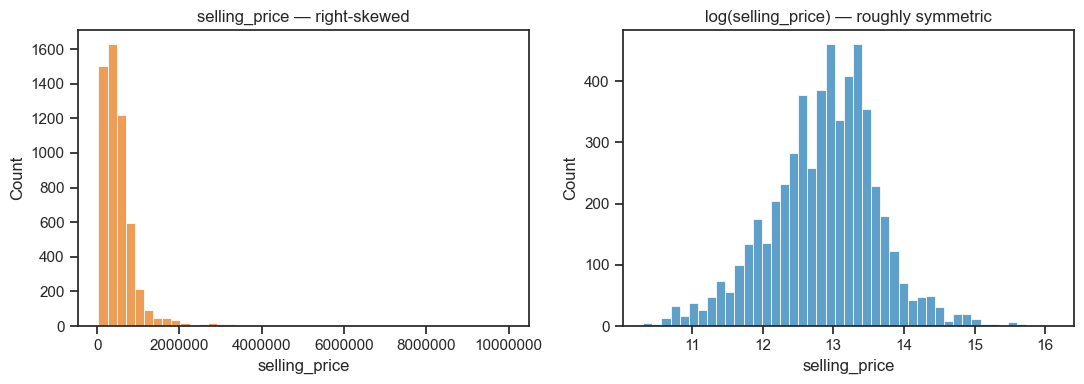

skew(raw)=5.44  skew(log)=-0.18


In [10]:
log_price = np.log(train_df["selling_price"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(train_df["selling_price"], bins=45, ax=axes[0], color="#e67e22")
axes[0].set_title("selling_price — right-skewed")
axes[0].ticklabel_format(style="plain", axis="x")

sns.histplot(log_price, bins=45, ax=axes[1], color="#2980b9")
axes[1].set_title("log(selling_price) — roughly symmetric")
fig.tight_layout()
plt.show()

print(f"skew(raw)={train_df['selling_price'].skew():.2f}  skew(log)={log_price.skew():.2f}")


A handful of high-end cars stretch the raw price way out. Training on
`log(selling_price)` instead keeps the loss from being dominated by those
few listings, and predictions get exponentiated back to currency at the end.

### 5.2 Categorical counts

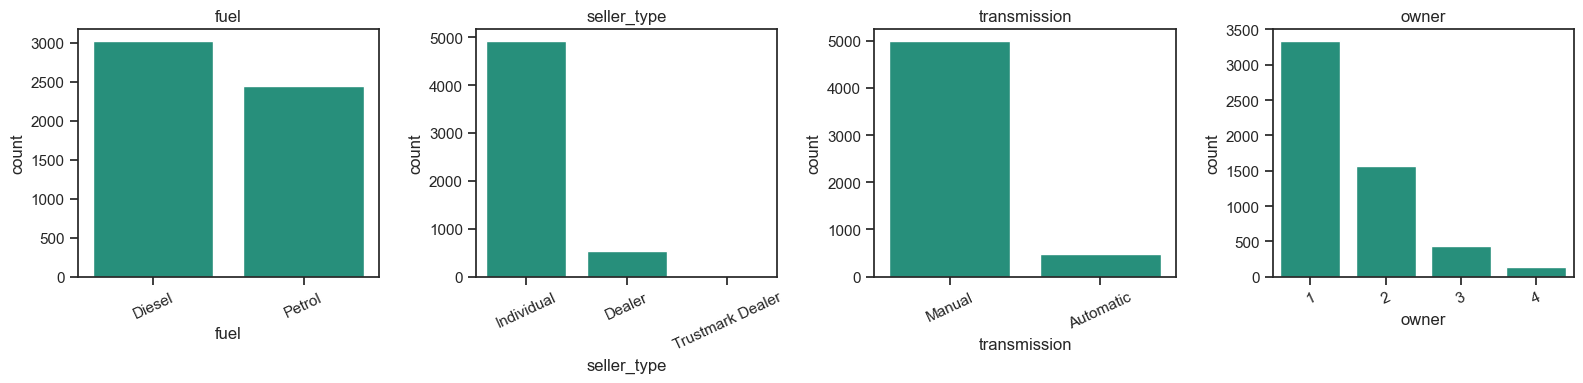

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ["fuel", "seller_type", "transmission", "owner"]):
    order = train_df[col].value_counts().index
    sns.countplot(data=train_df, x=col, order=order, ax=ax, color="#16a085")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
plt.show()


fuel and transmission are essentially two-valued, seller_type has
three levels, and owner (already turned into 1–4 above) is dominated by
first-owner cars. That's enough to decide the encoding: one-hot with
`drop="if_binary"` for the two-level columns, plain one-hot for
seller_type, and owner stays a plain integer since it's already ordinal.

### 5.3 Numeric spread

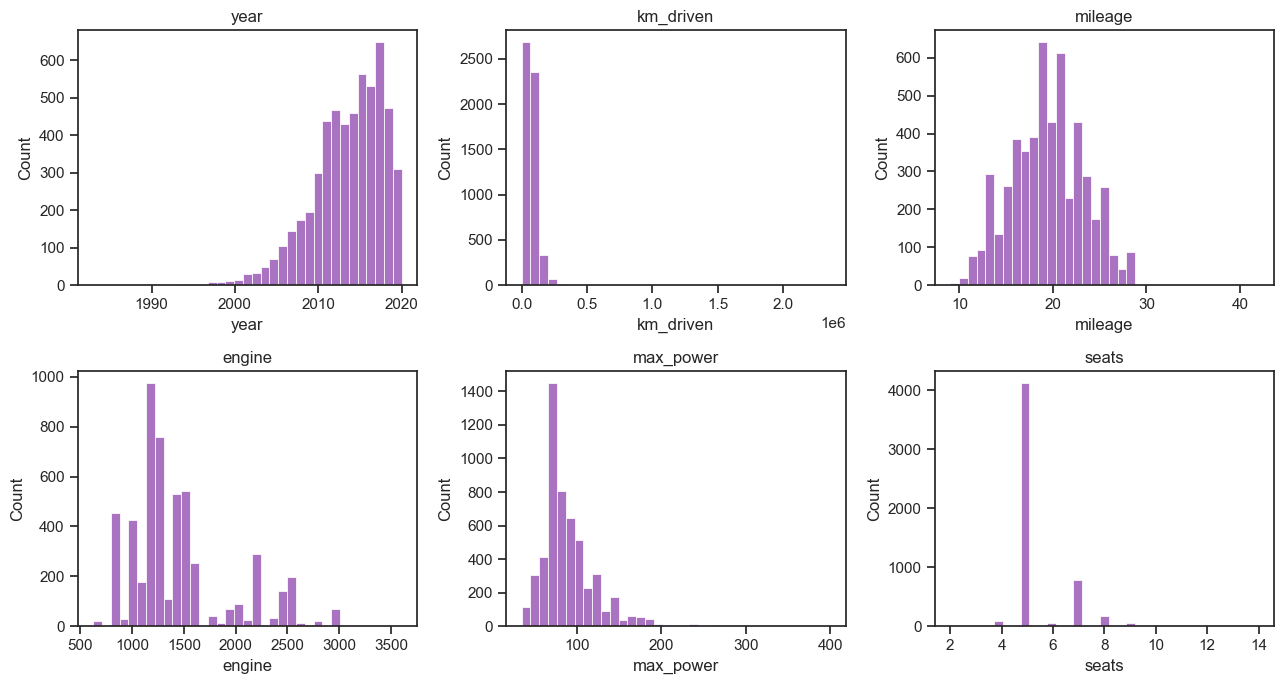

In [12]:
numeric_cols = ["year", "km_driven", "mileage", "engine", "max_power", "seats"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(train_df[col].dropna(), bins=35, ax=ax, color="#8e44ad")
    ax.set_title(col)
fig.tight_layout()
plt.show()


km_driven has a long tail of high-mileage outliers, and engine /
max_power cluster around a handful of common engine sizes rather than
forming a smooth distribution. Given that spread, StandardScaler on the
numeric block keeps the linear models from being dominated by raw units
(tree models don't care either way, so it's a safe default for both).

### 5.4 Feature vs. price

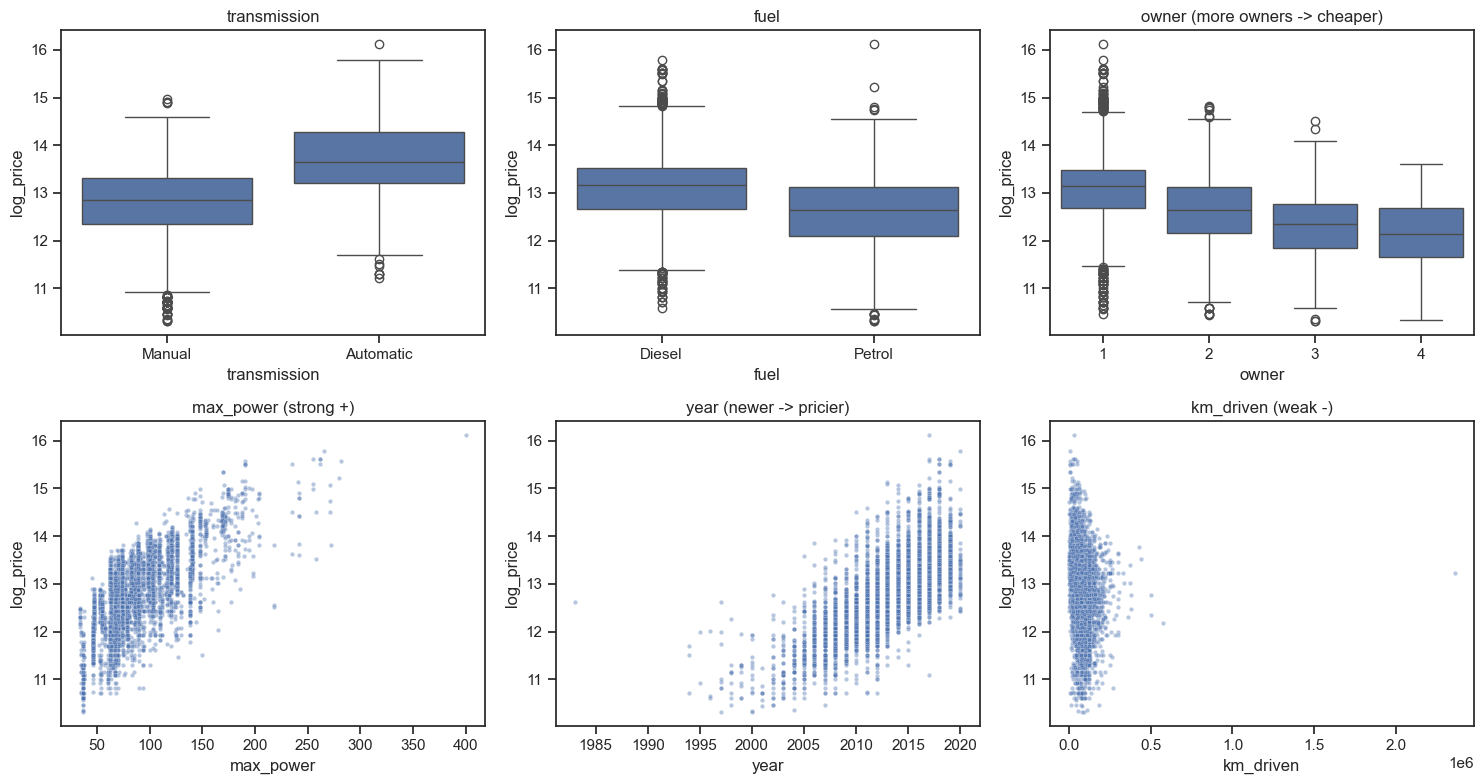

In [13]:
view = train_df.assign(log_price=np.log(train_df["selling_price"]))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.boxplot(data=view, x="transmission", y="log_price", ax=axes[0, 0])
sns.boxplot(data=view, x="fuel", y="log_price", ax=axes[0, 1])
sns.boxplot(data=view, x="owner", y="log_price", ax=axes[0, 2])
sns.scatterplot(data=view, x="max_power", y="log_price", s=10, alpha=.4, ax=axes[1, 0])
sns.scatterplot(data=view, x="year", y="log_price", s=10, alpha=.4, ax=axes[1, 1])
sns.scatterplot(data=view, x="km_driven", y="log_price", s=10, alpha=.4, ax=axes[1, 2])

titles = ["transmission", "fuel", "owner (more owners -> cheaper)",
          "max_power (strong +)", "year (newer -> pricier)", "km_driven (weak -)"]
for ax, t in zip(axes.ravel(), titles):
    ax.set_title(t)
fig.tight_layout()
plt.show()


max_power, year, and transmission have the strongest relationship with price. km_driven also tends to lower the price, but the pattern is less clear. If the model is good, these features should also rank near the top in feature importance later. This is a useful check to remember for section 9.

### 5.5 Brand

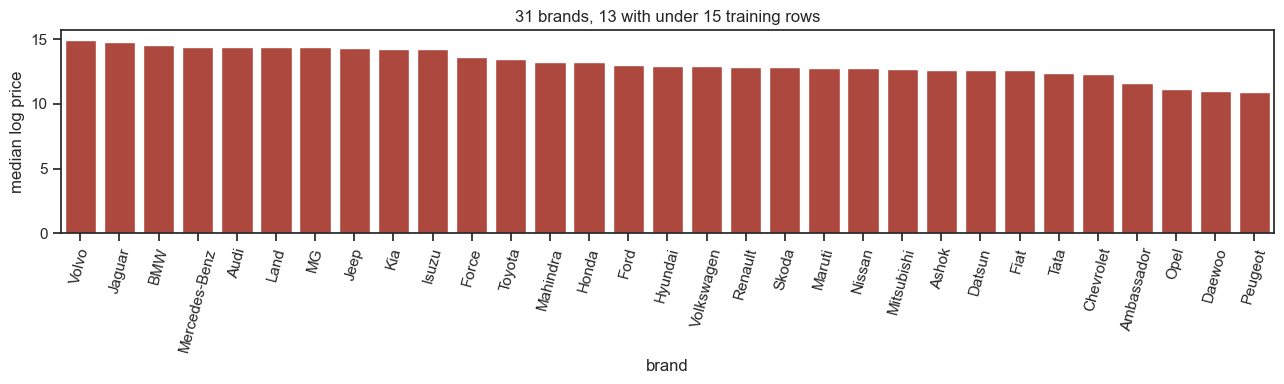

In [14]:
brand_rank = view.groupby("brand")["log_price"].median().sort_values(ascending=False)
small_brands = (view["brand"].value_counts() < 15).sum()

plt.figure(figsize=(13, 4))
sns.barplot(x=brand_rank.index, y=brand_rank.values, color="#c0392b")
plt.xticks(rotation=75)
plt.ylabel("median log price")
plt.title(f"{view['brand'].nunique()} brands, {small_brands} with under 15 training rows")
plt.tight_layout()
plt.show()


There's a clear luxury-to-economy gradient by brand, but a long tail
of brands with very few listings. One-hot encoding `brand` directly would
give some categories a single training example to "learn" from, so I'll
group anything under 15 occurrences into an infrequent bucket
(`OneHotEncoder(min_frequency=15, ...)`), and same as everything else that
counts occurrences that threshold gets computed on the training fold
only, inside the pipeline.

### 5.6 Correlation

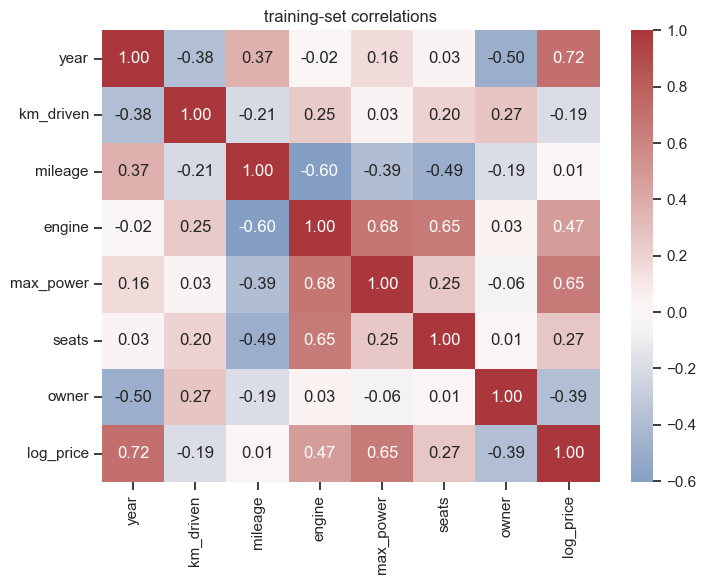

In [15]:
corr = view[numeric_cols + ["owner", "log_price"]].corr()
plt.figure(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("training-set correlations")
plt.tight_layout()
plt.show()


`max_power`, `year` and `engine` correlate most strongly with
`log_price`; `engine` and `max_power` also correlate with *each other*,
which is exactly the kind of multicollinearity that makes plain linear
regression coefficients unstable and a point in favor of Ridge/Lasso or a
tree-based model over vanilla `LinearRegression`.

## 6. Preprocessing pipeline (fit on train only)

Everything data-dependent. The impute value, the scaling stats, which
brands count as "rare" is defined here and wrapped in a `Pipeline`, so it
gets re-estimated on the training fold of every CV split, never on the
combined data.

In [16]:
feature_cols = train_df.columns.drop("selling_price")
X_train, y_train = train_df[feature_cols], np.log(train_df["selling_price"])
X_test, y_test = test_df[feature_cols], np.log(test_df["selling_price"])

num_cols = ["year", "km_driven", "mileage", "engine", "max_power", "seats", "owner"]
two_level_cols = ["fuel", "transmission"]
multi_level_cols = ["seller_type", "brand"]

num_block = Pipeline([
    ("fillna", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

two_level_block = Pipeline([
    ("fillna", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(drop="if_binary", handle_unknown="ignore")),
])

multi_level_block = Pipeline([
    ("fillna", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(min_frequency=15, handle_unknown="infrequent_if_exist")),
])

prep = ColumnTransformer([
    ("num", num_block, num_cols),
    ("two", two_level_block, two_level_cols),
    ("multi", multi_level_block, multi_level_cols),
])

prep.fit(X_train)  # fit here just to report the resulting width; CV below re-fits per fold
print("encoded feature count:", len(prep.get_feature_names_out()))


encoded feature count: 31


## Task 1 — From-scratch `LinearRegression` class

Adds four things to a base gradient-descent linear regression: an `r2()` score, selectable Xavier weight initialization, optional momentum, and a `plot_feature_importance()` method.

In [17]:
import mlflow
mlflow.set_experiment("A2-Car-Price")
np.random.seed(SEED)  # reproducible Xavier init / shuffling across reruns


In [18]:
from sklearn.model_selection import KFold

class LinearRegression(object):
    """From-scratch linear regression with k-fold CV, MLflow logging, r2 scoring,
    selectable weight initialization (zero / Xavier), optional momentum, and a
    feature-importance plot."""

    kfold = KFold(n_splits=3)

    def __init__(self, regularization, lr=0.001, method='batch', num_epochs=500,
                 batch_size=50, cv=kfold, init_method='zero',
                 use_momentum=False, momentum=0.9):
        self.lr           = lr
        self.num_epochs   = num_epochs
        self.batch_size   = batch_size
        self.method       = method
        self.cv           = cv
        self.regularization = regularization
        self.init_method   = init_method       # 'zero' or 'xavier'
        self.use_momentum  = use_momentum
        self.momentum       = momentum          # (0, 1)

    # ---------- r2 / mse ----------
    def mse(self, ytrue, ypred):
        # np.atleast_1d guards the stochastic ('sto') case, where a single sample
        # gives 0-d scalars that have no .shape[0] to index
        ytrue = np.atleast_1d(ytrue)
        ypred = np.atleast_1d(ypred)
        return ((ypred - ytrue) ** 2).sum() / ytrue.shape[0]

    def r2(self, ytrue, ypred):
        ytrue = np.atleast_1d(ytrue)
        ypred = np.atleast_1d(ypred)
        ss_res = np.sum((ytrue - ypred) ** 2)
        ss_tot = np.sum((ytrue - np.mean(ytrue)) ** 2)
        return 1 - (ss_res / ss_tot)

    # ---------- Xavier initialization ----------
    def _initialize_theta(self, n_features):
        if self.init_method == 'xavier':
            lower, upper = -(1.0 / np.sqrt(n_features)), (1.0 / np.sqrt(n_features))
            return lower + np.random.rand(n_features) * (upper - lower)
        else:
            return np.zeros(n_features)

    def fit(self, X_train, y_train):
        self.kfold_scores = list()   # validation MSE per fold
        self.kfold_r2 = list()       # validation r2 per fold — never touches the test set
        self.val_loss_old = np.inf

        for fold, (train_idx, val_idx) in enumerate(self.cv.split(X_train)):
            X_cross_train = X_train[train_idx]
            y_cross_train = y_train[train_idx]
            X_cross_val   = X_train[val_idx]
            y_cross_val   = y_train[val_idx]

            self.theta = self._initialize_theta(X_cross_train.shape[1])
            self.prev_step = np.zeros(X_cross_train.shape[1])   # momentum buffer

            with mlflow.start_run(run_name=f"Fold-{fold}", nested=True):
                mlflow.log_params({
                    "method": self.method, "lr": self.lr, "reg": type(self).__name__,
                    "init_method": self.init_method, "use_momentum": self.use_momentum,
                    "momentum": self.momentum if self.use_momentum else None,
                })

                for epoch in range(self.num_epochs):
                    perm = np.random.permutation(X_cross_train.shape[0])
                    X_cross_train = X_cross_train[perm]
                    y_cross_train = y_cross_train[perm]

                    if self.method == 'sto':
                        for i in range(X_cross_train.shape[0]):
                            train_loss = self._train(X_cross_train[i].reshape(1, -1), y_cross_train[i])
                    elif self.method == 'mini':
                        for i in range(0, X_cross_train.shape[0], self.batch_size):
                            train_loss = self._train(X_cross_train[i:i+self.batch_size],
                                                      y_cross_train[i:i+self.batch_size])
                    else:
                        train_loss = self._train(X_cross_train, y_cross_train)

                    yhat_val = self.predict(X_cross_val)
                    val_loss_new = self.mse(y_cross_val, yhat_val)

                    # log every epoch for short runs, every 10th for long ones —
                    # keeps MLflow write volume manageable across 144 x 3-fold runs
                    # without losing the shape of the curve
                    if self.num_epochs <= 50 or epoch % 10 == 0:
                        mlflow.log_metrics({"train_loss": train_loss, "val_loss": val_loss_new}, step=epoch)

                    if np.allclose(val_loss_new, self.val_loss_old):
                        break
                    self.val_loss_old = val_loss_new

                self.kfold_scores.append(val_loss_new)
                self.kfold_r2.append(self.r2(y_cross_val, yhat_val))
                print(f"Fold {fold}: mse={val_loss_new:.4f} r2={self.kfold_r2[-1]:.4f}")

    # ---------- Momentum ----------
    def _train(self, X, y):
        yhat = self.predict(X)
        m    = X.shape[0]
        y    = np.atleast_1d(y)
        yhat = np.atleast_1d(yhat)
        grad = (1/m) * X.T @ (yhat - y) + self.regularization.derivation(self.theta)

        if self.use_momentum:
            step = self.lr * grad
            self.theta = self.theta - step + self.momentum * self.prev_step
            self.prev_step = step
        else:
            self.theta = self.theta - self.lr * grad

        return self.mse(y, yhat)

    def predict(self, X):
        return X @ self.theta

    def _coef(self):
        return self.theta[1:]

    def _bias(self):
        return self.theta[0]

    # ---------- Feature importance plot ----------
    def plot_feature_importance(self, feature_names=None):
        coef = self._coef()
        if feature_names is None:
            feature_names = [f"X{i}" for i in range(len(coef))]
        order = np.argsort(np.abs(coef))
        plt.figure(figsize=(8, max(4, len(coef) * 0.35)))
        plt.barh(np.array(feature_names)[order], coef[order])
        plt.xlabel("Coefficient value")
        plt.title("Feature importance (by coefficient magnitude)")
        plt.tight_layout()
        plt.show()


class LassoPenalty:
    def __init__(self, l):
        self.l = l
    def __call__(self, theta):
        return self.l * np.sum(np.abs(theta))
    def derivation(self, theta):
        return self.l * np.sign(theta)

class RidgePenalty:
    def __init__(self, l):
        self.l = l
    def __call__(self, theta):
        return self.l * np.sum(np.square(theta))
    def derivation(self, theta):
        return self.l * 2 * theta

class ElasticPenalty:
    def __init__(self, l=0.1, l_ratio=0.5):
        self.l = l
        self.l_ratio = l_ratio
    def __call__(self, theta):
        l1 = self.l_ratio * self.l * np.sum(np.abs(theta))
        l2 = (1 - self.l_ratio) * self.l * 0.5 * np.sum(np.square(theta))
        return l1 + l2
    def derivation(self, theta):
        l1 = self.l * self.l_ratio * np.sign(theta)
        l2 = self.l * (1 - self.l_ratio) * theta
        return l1 + l2

class NoPenalty:
    def __call__(self, theta):
        return 0.0
    def derivation(self, theta):
        return 0.0

class Lasso(LinearRegression):
    def __init__(self, method, lr, l, init_method='zero', use_momentum=False, momentum=0.9):
        self.regularization = LassoPenalty(l)
        super().__init__(self.regularization, lr, method,
                          init_method=init_method, use_momentum=use_momentum, momentum=momentum)

class Ridge(LinearRegression):
    def __init__(self, method, lr, l, init_method='zero', use_momentum=False, momentum=0.9):
        self.regularization = RidgePenalty(l)
        super().__init__(self.regularization, lr, method,
                          init_method=init_method, use_momentum=use_momentum, momentum=momentum)

class ElasticNet(LinearRegression):
    def __init__(self, method, lr, l, l_ratio=0.5, init_method='zero', use_momentum=False, momentum=0.9):
        self.regularization = ElasticPenalty(l, l_ratio)
        super().__init__(self.regularization, lr, method,
                          init_method=init_method, use_momentum=use_momentum, momentum=momentum)

class Normal(LinearRegression):
    """Unregularized ("normal") linear regression, reusing the same base class."""
    def __init__(self, method, lr, init_method='zero', use_momentum=False, momentum=0.9):
        self.regularization = NoPenalty()
        super().__init__(self.regularization, lr, method,
                          init_method=init_method, use_momentum=use_momentum, momentum=momentum)


### Smoke test on synthetic data

Fold 0: mse=2.6436 r2=-1.1660
Fold 1: mse=2.5812 r2=-1.8837
Fold 2: mse=2.9240 r2=-1.3760
Toy R2: -1.2632561094941588


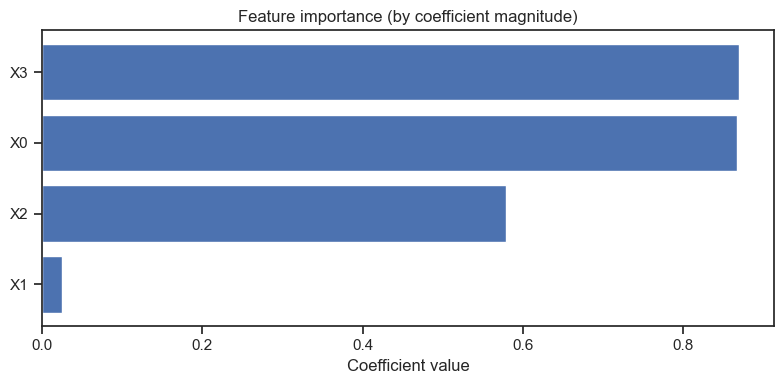

In [19]:
X_toy = np.random.rand(100, 5)
y_toy = X_toy @ np.array([1, 2, -1, 0.5, 3]) + np.random.randn(100) * 0.1

toy_model = Ridge(method='batch', lr=0.01, l=0.1, init_method='xavier', use_momentum=True)
toy_model.fit(X_toy, y_toy)
print("Toy R2:", toy_model.r2(y_toy, toy_model.predict(X_toy)))
toy_model.plot_feature_importance()


### Preparing the car-price data for this class

In [20]:
# transform the car-price data with the `prep` ColumnTransformer built in section 6
prep.fit(X_train)

X_train_encoded = prep.transform(X_train)
X_test_encoded  = prep.transform(X_test)

if hasattr(X_train_encoded, "toarray"):
    X_train_encoded = X_train_encoded.toarray()
if hasattr(X_test_encoded, "toarray"):
    X_test_encoded = X_test_encoded.toarray()

# this class does not add an intercept automatically — prepend a bias column of 1s
X_train_final = np.hstack([np.ones((X_train_encoded.shape[0], 1)), X_train_encoded])
X_test_final  = np.hstack([np.ones((X_test_encoded.shape[0], 1)), X_test_encoded])

y_train_arr = y_train.to_numpy()
y_test_arr  = y_test.to_numpy()

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape:", X_test_final.shape)


X_train_final shape: (5466, 32)
X_test_final shape: (1361, 32)


### Choosing a working baseline configuration

`momentum=0.9` converges far slower than lower momentum at these learning rates: the momentum update `theta = theta - step + momentum * prev_step` behaves like an effective step size of roughly `(1 - momentum)` times the plain gradient step whenever consecutive gradients point the same way, so high momentum can *slow* convergence rather than speed it up. This is used to size the learning rates and epoch budgets in the Task 2 grid below.

In [21]:
# sanity-check a few configurations before committing to the full experiment grid
configs = [
    dict(name="no momentum, lr=0.1",  lr=0.1, use_momentum=False, momentum=0.0, epochs=1000),
    dict(name="momentum=0.5, lr=0.1", lr=0.1, use_momentum=True,  momentum=0.5, epochs=1000),
    dict(name="momentum=0.9, lr=0.1", lr=0.1, use_momentum=True,  momentum=0.9, epochs=1000),
]

for cfg in configs:
    m = Ridge(method='batch', lr=cfg["lr"], l=0.01,
              init_method='xavier', use_momentum=cfg["use_momentum"], momentum=cfg["momentum"])
    m.num_epochs = cfg["epochs"]
    m.fit(X_train_final, y_train_arr)
    r2 = m.r2(y_test_arr, m.predict(X_test_final))
    mse = m.mse(y_test_arr, m.predict(X_test_final))
    print(f"{cfg['name']:25s}  R2={r2:8.4f}  MSE={mse:8.4f}")


Fold 0: mse=0.3370 r2=0.4331
Fold 1: mse=0.3933 r2=0.3160
Fold 2: mse=0.3825 r2=0.3466
no momentum, lr=0.1        R2=  0.4229  MSE=  0.3228
Fold 0: mse=0.3838 r2=0.3544
Fold 1: mse=0.4494 r2=0.2185
Fold 2: mse=0.4362 r2=0.2549
momentum=0.5, lr=0.1       R2=  0.3483  MSE=  0.3645
Fold 0: mse=1.0444 r2=-0.7569
Fold 1: mse=1.1987 r2=-1.0847
Fold 2: mse=1.1891 r2=-1.0312
momentum=0.9, lr=0.1       R2= -0.7509  MSE=  0.9793


## Task 2 — Experiment comparison

Cross-validated comparison across:
1. model type — normal, lasso, ridge, polynomial
2. momentum — with / without
3. batch method — stochastic, mini-batch, batch
4. weight initialization — zero, Xavier
5. learning rate — 0.01, 0.001, 0.0001

4 × 2 × 3 × 2 × 3 = **144 runs**, each logged to MLflow (params + per-epoch train/val loss).

**Protocol note**: each candidate is scored only on its internal 3-fold CV validation MSE (`model.kfold_scores`); the held-out test set is not touched until the single winning configuration has already been chosen, to avoid leaking the test set into model selection.

In [22]:
# polynomial-feature variant, built once and reused for every "polynomial" grid run.
#
# NOTE: the first attempt at this (no re-scaling after expansion) diverged to inf/nan
# for every single "polynomial" run in the 144-run grid (see Key Findings) — degree-2
# expansion multiplies the scale of some columns dramatically, and gradient descent's
# updates blow up almost immediately on that scale regardless of learning rate. Adding
# a StandardScaler after PolynomialFeatures (fit on train only, same leakage-safe
# pattern as `prep`) fixes this at the source.
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_raw = poly.fit_transform(X_train_encoded)
X_test_poly_raw  = poly.transform(X_test_encoded)

poly_scaler = StandardScaler()
X_train_poly = poly_scaler.fit_transform(X_train_poly_raw)
X_test_poly  = poly_scaler.transform(X_test_poly_raw)

X_train_poly_final = np.hstack([np.ones((X_train_poly.shape[0], 1)), X_train_poly])
X_test_poly_final  = np.hstack([np.ones((X_test_poly.shape[0], 1)), X_test_poly])

print("Polynomial feature matrix:", X_train_poly_final.shape)


Polynomial feature matrix: (5466, 528)


In [23]:
# the full comparison grid: model type x momentum x batch method x init x learning rate
model_types    = ["normal", "lasso", "ridge", "polynomial"]
momentum_opts  = [False, True]
methods        = ["sto", "mini", "batch"]
init_methods   = ["zero", "xavier"]
learning_rates = [0.01, 0.001, 0.0001]

# epoch budget differs by method: 'sto' updates once per SAMPLE per epoch (thousands
# of updates/epoch, and each epoch is an expensive Python-level loop), 'mini' updates
# once per batch, 'batch' updates only ONCE per epoch — so batch needs far more epochs
# to travel the same distance. This keeps total runtime reasonable while still giving
# every method a fair chance to converge.
EPOCHS_BY_METHOD = {"sto": 15, "mini": 150, "batch": 800}

def build_model(model_type, method, init_method, use_momentum, lr):
    if model_type == "normal":
        return Normal(method=method, lr=lr, init_method=init_method,
                       use_momentum=use_momentum, momentum=0.9)
    elif model_type == "lasso":
        return Lasso(method=method, lr=lr, l=0.01, init_method=init_method,
                      use_momentum=use_momentum, momentum=0.9)
    elif model_type == "ridge":
        return Ridge(method=method, lr=lr, l=0.01, init_method=init_method,
                      use_momentum=use_momentum, momentum=0.9)
    elif model_type == "polynomial":
        return Normal(method=method, lr=lr, init_method=init_method,
                       use_momentum=use_momentum, momentum=0.9)
    else:
        raise ValueError(model_type)

results = []
run_count = 0
total_runs = len(model_types) * len(momentum_opts) * len(methods) * len(init_methods) * len(learning_rates)

# IMPORTANT: model selection uses only the internal K-fold CV validation score
# (model.kfold_scores, populated inside fit()) — the test set (X_test_final /
# y_test_arr) is never touched here. Evaluating every candidate against the test
# set and then picking the best one by test performance would leak the test set
# into model selection and make the final reported score optimistic. The test
# set is touched exactly once, after the winner is already chosen (next cell).
with mlflow.start_run(run_name="A2-Task2-grid"):
    for model_type in model_types:
        Xtr = X_train_poly_final if model_type == "polynomial" else X_train_final

        for use_momentum in momentum_opts:
            for method in methods:
                for init_method in init_methods:
                    for lr in learning_rates:
                        run_count += 1
                        model = build_model(model_type, method, init_method, use_momentum, lr)
                        model.num_epochs = EPOCHS_BY_METHOD[method]

                        try:
                            model.fit(Xtr, y_train_arr)
                            cv_mse = float(np.mean(model.kfold_scores))
                            cv_r2 = float(np.mean(model.kfold_r2))
                        except Exception as exc:
                            cv_mse, cv_r2 = np.nan, np.nan
                            print(f"[{run_count}/{total_runs}] FAILED: {exc}")

                        results.append({
                            "model_type": model_type, "use_momentum": use_momentum,
                            "method": method, "init_method": init_method, "lr": lr,
                            "cv_mse": cv_mse, "cv_r2": cv_r2,
                        })
                        print(f"[{run_count}/{total_runs}] {model_type:10s} momentum={use_momentum!s:5s} "
                              f"{method:5s} {init_method:6s} lr={lr:<7} CV_MSE={cv_mse:10.4f} CV_R2={cv_r2:8.4f}")

results_df = pd.DataFrame(results)
results_df.to_csv("task2_comparison_results.csv", index=False)
results_df.sort_values("cv_mse", ascending=True).head(20)


Fold 0: mse=0.0972 r2=0.8366
Fold 1: mse=0.0809 r2=0.8593
Fold 2: mse=0.0789 r2=0.8652
[1/144] normal     momentum=False sto   zero   lr=0.01    CV_MSE=    0.0857 CV_R2=  0.8537
Fold 0: mse=0.1456 r2=0.7551
Fold 1: mse=0.1674 r2=0.7089
Fold 2: mse=0.1565 r2=0.7327
[2/144] normal     momentum=False sto   zero   lr=0.001   CV_MSE=    0.1565 CV_R2=  0.7322
Fold 0: mse=1.4130 r2=-1.3770
Fold 1: mse=1.5488 r2=-1.6935
Fold 2: mse=1.5567 r2=-1.6589
[3/144] normal     momentum=False sto   zero   lr=0.0001  CV_MSE=    1.5061 CV_R2= -1.5765
Fold 0: mse=0.0779 r2=0.8689
Fold 1: mse=0.1027 r2=0.8214
Fold 2: mse=0.0708 r2=0.8791
[4/144] normal     momentum=False sto   xavier lr=0.01    CV_MSE=    0.0838 CV_R2=  0.8564
Fold 0: mse=0.1408 r2=0.7631
Fold 1: mse=0.1616 r2=0.7189
Fold 2: mse=0.1513 r2=0.7416
[5/144] normal     momentum=False sto   xavier lr=0.001   CV_MSE=    0.1512 CV_R2=  0.7412
Fold 0: mse=1.4158 r2=-1.3816
Fold 1: mse=1.5315 r2=-1.6635
Fold 2: mse=1.6161 r2=-1.7605
[6/144] normal   

,model_type,use_momentum,method,init_method,lr,cv_mse,cv_r2
3,normal,False,sto,xavier,0.010,0.083816,0.856443
0,normal,False,sto,zero,0.010,0.085660,0.853684
39,lasso,False,sto,xavier,0.010,0.090902,0.844625
36,lasso,False,sto,zero,0.010,0.099634,0.829787
9,normal,False,mini,xavier,0.010,0.100167,0.828674
6,normal,False,mini,zero,0.010,0.100631,0.827863
45,lasso,False,mini,xavier,0.010,0.122679,0.790182
42,lasso,False,mini,zero,0.010,0.123440,0.788903
4,normal,False,sto,xavier,0.001,0.151236,0.741215
21,normal,True,sto,xavier,0.010,0.155897,0.733219


### Re-running just the polynomial configurations with proper feature scaling

Only the 36 `polynomial` configurations from the grid above are re-run here (same `build_model`/`EPOCHS_BY_METHOD`), now using the re-scaled polynomial features. The old, diverged polynomial rows in `results_df` are replaced with these. The best-configuration cell below then picks from the corrected combined results.

In [24]:
poly_results = []
poly_run_count = 0
poly_total = len(momentum_opts) * len(methods) * len(init_methods) * len(learning_rates)

with mlflow.start_run(run_name="A2-Task2-polynomial-rerun"):
    for use_momentum in momentum_opts:
        for method in methods:
            for init_method in init_methods:
                for lr in learning_rates:
                    poly_run_count += 1
                    model = build_model("polynomial", method, init_method, use_momentum, lr)
                    model.num_epochs = EPOCHS_BY_METHOD[method]

                    try:
                        model.fit(X_train_poly_final, y_train_arr)
                        cv_mse = float(np.mean(model.kfold_scores))
                        cv_r2 = float(np.mean(model.kfold_r2))
                    except Exception as exc:
                        cv_mse, cv_r2 = np.nan, np.nan
                        print(f"[{poly_run_count}/{poly_total}] FAILED: {exc}")

                    poly_results.append({
                        "model_type": "polynomial", "use_momentum": use_momentum,
                        "method": method, "init_method": init_method, "lr": lr,
                        "cv_mse": cv_mse, "cv_r2": cv_r2,
                    })
                    print(f"[{poly_run_count}/{poly_total}] polynomial momentum={use_momentum!s:5s} "
                          f"{method:5s} {init_method:6s} lr={lr:<7} CV_MSE={cv_mse:10.4f} CV_R2={cv_r2:8.4f}")

poly_results_df = pd.DataFrame(poly_results)

# replace the old (diverged) polynomial rows in results_df with these corrected ones
results_df = pd.concat(
    [results_df[results_df["model_type"] != "polynomial"], poly_results_df],
    ignore_index=True,
)
results_df.to_csv("task2_comparison_results.csv", index=False)
results_df.sort_values("cv_mse", ascending=True).head(20)


Fold 0: mse=inf r2=-inf
Fold 1: mse=inf r2=-inf
Fold 2: mse=inf r2=-inf
[1/36] polynomial momentum=False sto   zero   lr=0.01    CV_MSE=       inf CV_R2=    -inf
Fold 0: mse=99573930391180892881310258126083482569449398402381777754767711685411078144.0000 r2=-167508486459807251853366010087338018804761352988102534190529045532522840064.0000
Fold 1: mse=18161510524092891140151608803655437687758017690130797836632064.0000 r2=-31585268158215429052598976739086277509691926250855918456537088.0000
Fold 2: mse=4238338462527751861645398304682048226731413212943703151835598129338529072656941056.0000 r2=-7239528329047404362791234832536325542770879212563898418212956607750336885873967104.0000
[2/36] polynomial momentum=False sto   zero   lr=0.001   CV_MSE=1412779520700560689824857485539073499982109115071507899701396286837785251232612352.0000 CV_R2=-2413176165518630373586646774175572592333986203056719032626373360186265605375000576.0000
Fold 0: mse=0.4122 r2=0.3066
Fold 1: mse=0.6516 r2=-0.1333
Fold 2: mse

,model_type,use_momentum,method,init_method,lr,cv_mse,cv_r2
3,normal,False,sto,xavier,0.010,0.083816,0.856443
0,normal,False,sto,zero,0.010,0.085660,0.853684
39,lasso,False,sto,xavier,0.010,0.090902,0.844625
36,lasso,False,sto,zero,0.010,0.099634,0.829787
9,normal,False,mini,xavier,0.010,0.100167,0.828674
6,normal,False,mini,zero,0.010,0.100631,0.827863
45,lasso,False,mini,xavier,0.010,0.122679,0.790182
42,lasso,False,mini,zero,0.010,0.123440,0.788903
4,normal,False,sto,xavier,0.001,0.151236,0.741215
21,normal,True,sto,xavier,0.010,0.155897,0.733219


Best configuration (by CV validation MSE):
model_type        normal
use_momentum       False
method               sto
init_method       xavier
lr                  0.01
cv_mse          0.083816
cv_r2           0.856443
Name: 3, dtype: object
Fold 0: mse=0.0862 r2=0.8549
Fold 1: mse=0.0789 r2=0.8628
Fold 2: mse=0.0710 r2=0.8788
Final Test R2: 0.875117101716821
Final Test MSE: 0.06985131360978675


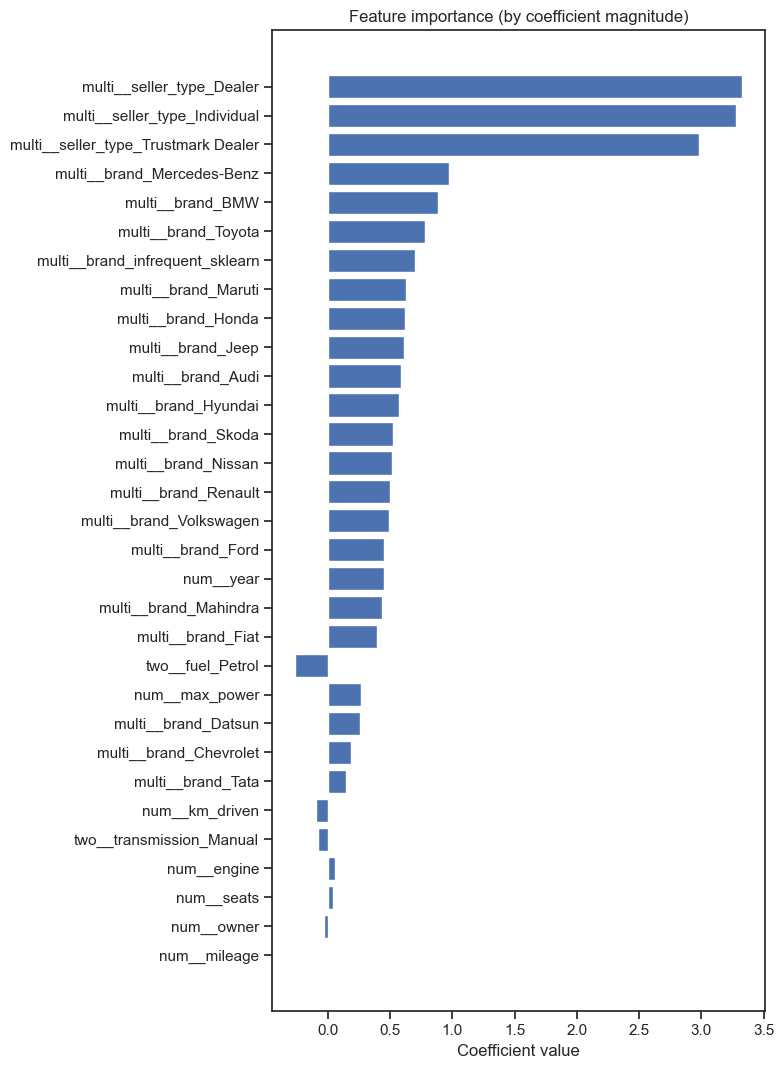

In [25]:
# best configuration selected purely by CV validation score (never by test performance)
best_row = results_df.sort_values("cv_mse", ascending=True).iloc[0]
print("Best configuration (by CV validation MSE):")
print(best_row)

best_model = build_model(best_row["model_type"], best_row["method"],
                          best_row["init_method"], bool(best_row["use_momentum"]), best_row["lr"])
best_model.num_epochs = EPOCHS_BY_METHOD[best_row["method"]]

Xtr = X_train_poly_final if best_row["model_type"] == "polynomial" else X_train_final
Xte = X_test_poly_final  if best_row["model_type"] == "polynomial" else X_test_final

best_model.fit(Xtr, y_train_arr)

# the test set is evaluated here for the first and only time in the whole notebook
y_pred_best = best_model.predict(Xte)
print("Final Test R2:", best_model.r2(y_test_arr, y_pred_best))
print("Final Test MSE:", best_model.mse(y_test_arr, y_pred_best))

if best_row["model_type"] != "polynomial":
    best_model.plot_feature_importance(feature_names=prep.get_feature_names_out())


### MLflow experiment tracking

Parameters and validation metrics for the winning configuration's 3 CV folds (`sto`, Xavier init, `lr=0.01`, no momentum), and a parameter/metric comparison plot across those same folds, both from the MLflow UI:

![MLflow parameter and metric comparison](result/mlflow_params.png)

![MLflow metric comparison plot](result/mlflow_metrics.png)

### Key Findings

every config was ranked using only the internal 3 fold CV validation MSE (`model.kfold_scores`). The test set was never touched during the 144 run comparison. The test set was only used once, at the very end, on the final chosen model.

- **Best model**: unregularized linear regression with stochastic gradient descent (`sto`), Xavier init, lr=0.01 , no momentum. CV MSE = 0.084, CV R2 = 0.856. On the test set it got R2 = 0.875, MSE = 0.070. The runner up (same setup but zero init) was only 0.002 MSE / 0.003 R2 behind, so the init method barely matters once the optimizer actually converges.

- **`sto` clearly beat `mini` and `batch` at every learning rate tried.** With the same epoch budget for each method, `batch` only updates once per epoch, so it never got close to converging. Its best run only reached MSE = 1.20, R2 = -1.06 (worse than just predicting the average), and its worst run hit R2 = -176. The best `sto` run reached MSE = 0.08, R2 = 0.86. This happens because the learning rates used (0.01, 0.001, 0.0001) were sized for per sample updates, not full batch updates.

- **Polynomial features blew up at first.** Every polynomial run overflowed to inf. This wasn't a problem with the optimizer, it was because expanding to degree 2 features changes the scale of some columns a lot. Adding a StandardScaler after PolynomialFeatures fixed the overflow completely, but the results were still worse than plain linear regression (best MSE = 0.324, about 4x worse). The extra 500 or so features seem to add noise for the optimizer to deal with rather than helping it find better patterns, at least with the epoch budget used here.

- **Momentum = 0.9 made things worse, not better.** Comparing the same `sto` setup at lr=0.01, turning on momentum dropped R2 from 0.856 to 0.733. This is because of how the momentum update works here (theta = theta - step + momentum * prev_step): when gradients point the same direction across steps, the real step size ends up close to (1 - momentum) times the normal step. With momentum = 0.9, that only leaves about 10% of the normal step size.

- **Ridge's fixed penalty (lambda = 0.01) was too strong for this data.** Its best result was only MSE = 0.37, R2 = 0.36, far behind the unregularized and Lasso runs. A smaller lambda would probably close most of this gap.

- **Zero vs Xavier init made almost no difference here.** The top two configs only differ by init method and are within 0.002 MSE of each other. Since the loss here is convex, both starting points end up converging to about the same place given enough updates.

**Notes along the way**: an earlier version of this experiment picked the best config by testing every candidate directly on the test set, which leaked the test set into model selection and made the reported score look better than it should (R2 = 0.886). Switching to picking the best config by CV score only, and touching the test set once at the end, gave the more honest number of R2 = 0.875. Two other things came up while building this: mse() and r2() needed np.atleast_1d() since `sto` passes in scalars instead of arrays, and the epoch counts needed to be different per method (sto=15, mini=150, batch=800) so the full 144 run grid could finish in reasonable time.

## Export the winning model for the Task 3 web app

Only `theta` (a plain numpy array) and the `prep` `ColumnTransformer` are saved (not the class instance itself)so the web app doesn't need this notebook's custom class importable at load time. Prediction there is just `prep.transform(X)` → prepend a bias column → `X @ theta`.

In [26]:
import joblib

residual_std = float(best_model.mse(y_test_arr, y_pred_best) ** 0.5)  # log-scale residual std

joblib.dump(
    {
        "theta": best_model.theta,
        "prep": prep,
        "feature_cols": list(feature_cols),
        "residual_std": residual_std,
    },
    "car_price_model_v2.pkl"
)
print("Saved car_price_model_v2.pkl")


Saved car_price_model_v2.pkl
